# Exploratory Data Analysis — Synthetic Gender Sensitization Survey
## ⚠️ SYNTHETIC DATA DISCLAIMER

**This entire notebook operates on `synthetic_survey.csv`, a 100% artificially
generated dataset.**

- No real survey respondents are represented in this file.
- The data was produced by a Python script (`generate_dataset.py`) using
  random sampling, loosely targeting the *aggregate* percentages published
  in a dissertation on gender sensitization in Kanpur — but **no real
  individual-level responses were ever used**.
- Some relationships between variables (e.g., education vs. awareness) were
  **deliberately and artificially injected** into the data generation process
  purely to make the dataset useful for analytics/ML demonstrations.
- **Do not** interpret any statistic, chart, or "finding" in this notebook as
  evidence about real attitudes, real people, or the real world. This is a
  technical demonstration only.


## 1. Import Libraries
Same core stack as the cleaning notebook: `pandas`, `numpy`, `matplotlib`, and `plotly` (both `express` and `graph_objects`).

In [1]:
# Import data-handling libraries
import pandas as pd
import numpy as np

# Import plotting libraries
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Configure matplotlib for clean, professional-looking static charts
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (9, 5)
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.titleweight'] = 'bold'

# A consistent color palette used across charts in this notebook
PALETTE = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B2', '#937860']

pd.set_option('display.max_columns', None)
print("Libraries imported successfully.")


Libraries imported successfully.


## 2. Load the Cleaned Synthetic Dataset
We load the cleaned file produced in `Data_Cleaning.ipynb`. If that file isn't available, we fall back to the raw synthetic CSV.

**Reminder: all data here is synthetic / artificially generated.**

In [2]:
# Try to load the cleaned dataset first; fall back to the raw file otherwise
import os

if os.path.exists("synthetic_survey_cleaned.csv"):
    df = pd.read_csv("synthetic_survey_cleaned.csv")
    print("Loaded 'synthetic_survey_cleaned.csv'.")
else:
    df = pd.read_csv("synthetic_survey.csv")
    print("Cleaned file not found — loaded raw 'synthetic_survey.csv' instead.")

print(f"Dataset shape: {df.shape[0]} rows x {df.shape[1]} columns")
print("\nReminder: this is a SYNTHETIC dataset — no real respondents are represented.")

df.head()


Loaded 'synthetic_survey_cleaned.csv'.
Dataset shape: 1000 rows x 28 columns

Reminder: this is a SYNTHETIC dataset — no real respondents are represented.


,respondent_id,age_group,gender,education,heard_term_gender_sensitization,gender_is_binary_or_nonbinary,received_gender_training,support_school_curriculum,support_workplace_training,sensitization_helps_relationships,stereotype_men_rational_women_emotional,stereotype_women_bad_drivers,view_okay_for_men_to_cry,stereotype_men_strong_women_weak,stereotype_women_better_housekeepers,stereotype_gentle_men_less_masculine,childcare_only_mother_responsibility,woman_home_man_provider_role,chores_divided_equally_if_both_work,support_equal_pay,support_gender_diversity_quotas,discrimination_observed_nearby,support_gender_neutral_language,encourage_girls_nontraditional_careers,man_should_have_final_say_home,woman_should_not_tolerate_violence,sexist_jokes_okay,sensitization_reduces_gbv
0,R0001,18-25,Female,Bachelor's degree,Yes,Non-binary,No,Maybe,"Yes, definitely",Yes,Agree,Disagree,Agree,Agree,Agree,Disagree,No,Yes,"Yes, definitely",Yes,Yes,No,Maybe,Yes,No,Maybe,No,Yes
1,R0002,18-25,Male,Bachelor's degree,No,Non-binary,No,"No, not required","Yes, definitely",Yes,Disagree,Disagree,Agree,Disagree,Disagree,Agree,Yes,Yes,"Yes, definitely",Yes,Yes,Yes,Yes,Yes,No,No,No,Maybe
2,R0003,18-25,Female,Bachelor's degree,Yes,Binary,Yes,"No, not required","Yes, definitely",Yes,Disagree,Neutral,Agree,Disagree,Agree,Disagree,No,Yes,"No, the woman should manage both",Yes,Yes,No,Yes,Maybe,No,No,No,Yes
3,R0004,18-25,Male,Master's degree,Yes,Binary,No,"Yes, definitely","Yes, definitely",Yes,Agree,Disagree,Agree,Disagree,Agree,Disagree,No,No,"No, the woman should manage both",Yes,Yes,No,Yes,Yes,No,No,No,Yes
4,R0005,26-35,Male,Master's degree,Yes,Non-binary,Yes,Maybe,Maybe,Yes,Disagree,Disagree,Agree,Disagree,Disagree,Disagree,No,Yes,"Yes, definitely",Yes,Unsure,Unsure,Maybe,Yes,No,Yes,Maybe,Yes


## 3. Re-apply Ordinal Ordering
When re-loading from CSV, pandas reverts ordered categories back to plain objects. We re-apply logical ordering for `age_group` and `education` so charts display categories in a sensible sequence.

In [3]:
# Re-establish logical ordering for ordinal columns after CSV reload
age_order = ["Less than 18", "18-25", "26-35", "More than 35"]
df["age_group"] = pd.Categorical(df["age_group"], categories=age_order, ordered=True)

edu_order = [
    "High school or equivalent",
    "Bachelor's degree",
    "Master's degree",
    "Doctoral or post-doctoral degree",
]
df["education"] = pd.Categorical(df["education"], categories=edu_order, ordered=True)

print("Ordinal ordering re-applied.")


Ordinal ordering re-applied.


## 4. Demographic Overview
We start by exploring the demographic composition of the synthetic sample: age group, gender, and education.

### 4.1 Age Group Distribution

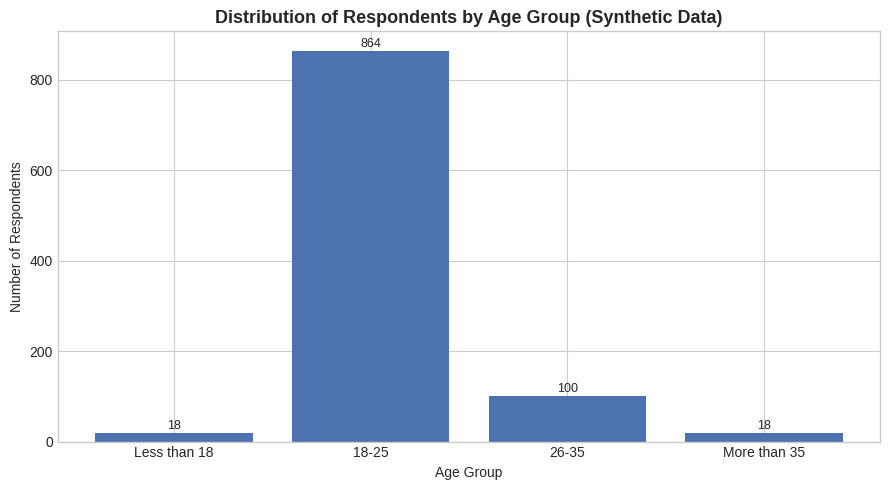

In [4]:
# Count respondents per age group, respecting the defined logical order
age_counts = df['age_group'].value_counts().reindex(age_order)

# --- Matplotlib static bar chart ---
fig, ax = plt.subplots()
bars = ax.bar(age_counts.index, age_counts.values, color=PALETTE[0])
ax.set_title("Distribution of Respondents by Age Group (Synthetic Data)")
ax.set_xlabel("Age Group")
ax.set_ylabel("Number of Respondents")

# Annotate each bar with its count for readability
for bar in bars:
    height = bar.get_height()
    ax.annotate(f'{int(height)}', xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3), textcoords="offset points", ha='center', fontsize=9)
plt.tight_layout()
plt.show()


In [5]:
# --- Plotly interactive bar chart (same data, interactive version) ---
fig = px.bar(
    x=age_counts.index, y=age_counts.values,
    labels={'x': 'Age Group', 'y': 'Number of Respondents'},
    title="Distribution of Respondents by Age Group (Synthetic Data)",
    color=age_counts.index,
    color_discrete_sequence=PALETTE,
    text=age_counts.values,
)
fig.update_traces(textposition='outside')
fig.update_layout(showlegend=False, template='plotly_white')
fig.show()


### 4.2 Gender Distribution

In [6]:
# Count respondents per gender
gender_counts = df['gender'].value_counts()

# --- Plotly interactive pie chart ---
fig = px.pie(
    values=gender_counts.values, names=gender_counts.index,
    title="Gender Distribution of Respondents (Synthetic Data)",
    color_discrete_sequence=PALETTE,
    hole=0.35,  # donut style for a modern look
)
fig.update_traces(textinfo='percent+label')
fig.update_layout(template='plotly_white')
fig.show()


### 4.3 Education Level Distribution

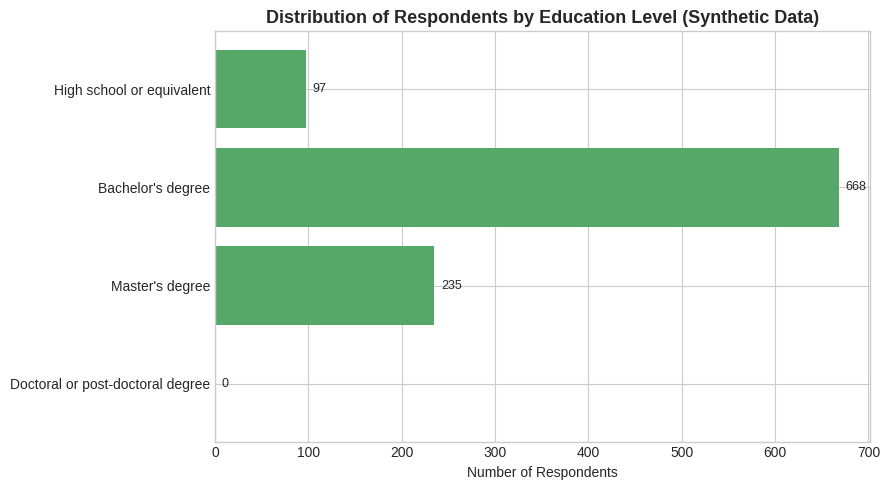

In [7]:
# Count respondents per education level, respecting logical order
edu_counts = df['education'].value_counts().reindex(edu_order)

fig, ax = plt.subplots()
bars = ax.barh(edu_counts.index, edu_counts.values, color=PALETTE[2])
ax.set_title("Distribution of Respondents by Education Level (Synthetic Data)")
ax.set_xlabel("Number of Respondents")
ax.invert_yaxis()  # highest qualification at top

for bar in bars:
    width = bar.get_width()
    ax.annotate(f'{int(width)}', xy=(width, bar.get_y() + bar.get_height() / 2),
                xytext=(5, 0), textcoords="offset points", va='center', fontsize=9)
plt.tight_layout()
plt.show()


## 5. Gender Sensitization Awareness
Exploring how many synthetic respondents reported having heard the term 'Gender Sensitization' and having received related training.

In [8]:
# Create a 1x2 subplot comparing awareness vs. training using Plotly
fig = make_subplots(rows=1, cols=2, subplot_titles=(
    "Heard of 'Gender Sensitization'", "Received Gender-Related Training"
))

heard_counts = df['heard_term_gender_sensitization'].value_counts()
training_counts = df['received_gender_training'].value_counts()

fig.add_trace(go.Bar(x=heard_counts.index, y=heard_counts.values,
                      marker_color=PALETTE[0], name="Heard Term"), row=1, col=1)
fig.add_trace(go.Bar(x=training_counts.index, y=training_counts.values,
                      marker_color=PALETTE[1], name="Received Training"), row=1, col=2)

fig.update_layout(
    title_text="Gender Sensitization Awareness & Training (Synthetic Data)",
    showlegend=False, template='plotly_white'
)
fig.show()


## 6. Cross-Tabulation: Awareness by Education Level
This explores the **synthetic, artificially injected** relationship between education level and awareness of the term 'Gender Sensitization' that was built into the data generation script. It is shown here purely to demonstrate cross-tabulation and grouped visualization techniques — it does not reflect any real-world finding.

Percentage who 'Heard the term' by education level (synthetic data):


heard_term_gender_sensitization,No,Yes
education,,
High school or equivalent,40.2,59.8
Bachelor's degree,25.3,74.7
Master's degree,20.9,79.1
Doctoral or post-doctoral degree,NaN,NaN


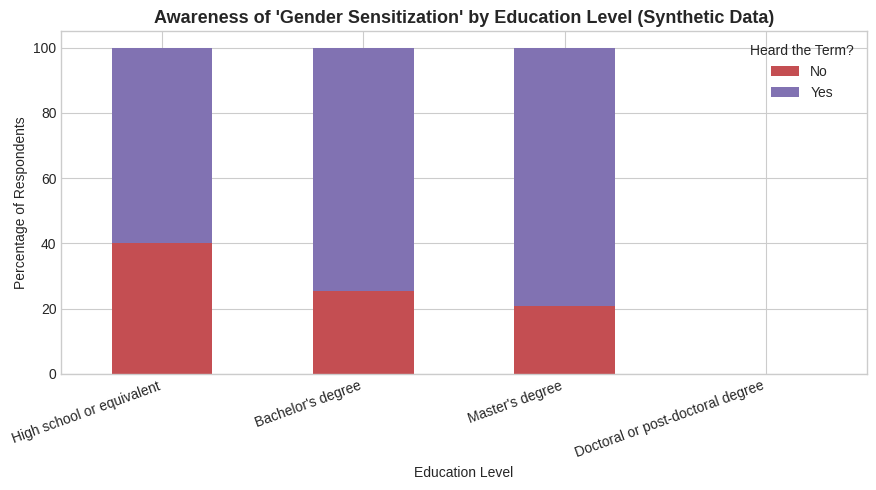

In [9]:
# Build a cross-tabulation of education level vs. awareness, normalized by row
crosstab = pd.crosstab(df['education'], df['heard_term_gender_sensitization'], normalize='index') * 100
crosstab = crosstab.reindex(edu_order)
print("Percentage who 'Heard the term' by education level (synthetic data):")
display(crosstab.round(1))

# --- Matplotlib stacked bar chart ---
fig, ax = plt.subplots()
crosstab.plot(kind='bar', stacked=True, color=[PALETTE[3], PALETTE[4]], ax=ax)
ax.set_title("Awareness of 'Gender Sensitization' by Education Level (Synthetic Data)")
ax.set_xlabel("Education Level")
ax.set_ylabel("Percentage of Respondents")
ax.legend(title="Heard the Term?")
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()


## 7. Gender Stereotype Attitudes
We visualize how synthetic respondents answered several stereotype statements, to see the overall pattern of agreement/disagreement/neutrality.

In [10]:
# List of stereotype-related columns to visualize together
stereotype_cols = [
    'stereotype_men_rational_women_emotional',
    'stereotype_women_bad_drivers',
    'view_okay_for_men_to_cry',
    'stereotype_men_strong_women_weak',
    'stereotype_women_better_housekeepers',
    'stereotype_gentle_men_less_masculine',
]

# Build a tidy summary table: for each statement, % Agree / Disagree / Neutral
summary_rows = []
for col in stereotype_cols:
    counts = df[col].value_counts(normalize=True) * 100
    summary_rows.append({
        'statement': col,
        'Agree': counts.get('Agree', 0),
        'Disagree': counts.get('Disagree', 0),
        'Neutral': counts.get('Neutral', 0),
    })
stereo_summary = pd.DataFrame(summary_rows).set_index('statement')
display(stereo_summary.round(1))

# --- Plotly horizontal stacked bar chart ---
fig = go.Figure()
fig.add_trace(go.Bar(y=stereo_summary.index, x=stereo_summary['Agree'],
                      name='Agree', orientation='h', marker_color=PALETTE[3]))
fig.add_trace(go.Bar(y=stereo_summary.index, x=stereo_summary['Neutral'],
                      name='Neutral', orientation='h', marker_color=PALETTE[5]))
fig.add_trace(go.Bar(y=stereo_summary.index, x=stereo_summary['Disagree'],
                      name='Disagree', orientation='h', marker_color=PALETTE[2]))

fig.update_layout(
    barmode='stack',
    title="Attitudes Toward Gender Stereotype Statements (Synthetic Data)",
    xaxis_title="Percentage of Respondents",
    template='plotly_white',
    legend_title="Response",
    height=500,
)
fig.show()


,Agree,Disagree,Neutral
statement,,,
stereotype_men_rational_women_emotional,39.2,40.1,20.7
stereotype_women_bad_drivers,20.7,60.6,18.7
view_okay_for_men_to_cry,86.4,10.1,3.5
stereotype_men_strong_women_weak,24.9,67.2,7.9
stereotype_women_better_housekeepers,28.8,55.5,15.7
stereotype_gentle_men_less_masculine,32.9,58.7,8.4


## 8. Gender Equality Attitudes
Visualizing support for equal pay, gender-diversity quotas, and gender-neutral language.

In [11]:
# Compare three gender-equality related columns side-by-side
equality_cols = ['support_equal_pay', 'support_gender_diversity_quotas', 'support_gender_neutral_language']
titles = ['Support: Equal Pay', 'Support: Gender Diversity Quotas', 'Support: Gender-Neutral Language']

fig = make_subplots(rows=1, cols=3, subplot_titles=titles)

for i, col in enumerate(equality_cols, start=1):
    counts = df[col].value_counts()
    fig.add_trace(
        go.Bar(x=counts.index, y=counts.values, marker_color=PALETTE[i % len(PALETTE)]),
        row=1, col=i
    )

fig.update_layout(
    title_text="Gender Equality Attitudes (Synthetic Data)",
    showlegend=False, template='plotly_white'
)
fig.show()


## 9. Gender-Based Violence Attitudes
Visualizing attitudes toward tolerance of violence, sexist jokes, and belief in the value of sensitization programs for reducing gender-based violence.

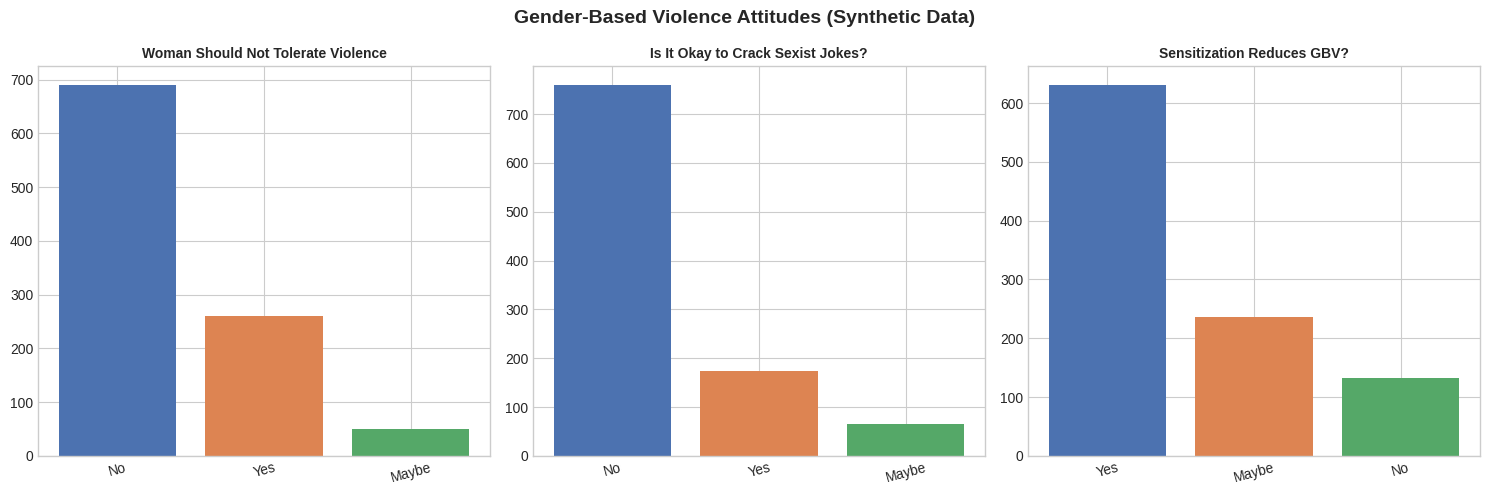

In [12]:
# Build counts for the three GBV-related questions
gbv_cols = ['woman_should_not_tolerate_violence', 'sexist_jokes_okay', 'sensitization_reduces_gbv']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
titles = [
    "Woman Should Not Tolerate Violence",
    "Is It Okay to Crack Sexist Jokes?",
    "Sensitization Reduces GBV?"
]

for ax, col, title in zip(axes, gbv_cols, titles):
    counts = df[col].value_counts()
    ax.bar(counts.index, counts.values, color=PALETTE[:len(counts)])
    ax.set_title(title, fontsize=10)
    ax.tick_params(axis='x', rotation=15)

fig.suptitle("Gender-Based Violence Attitudes (Synthetic Data)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


## 10. Gender Comparison: Support for Equal Pay
A simple grouped comparison of equal-pay support by respondent gender, to demonstrate grouped categorical comparisons.

In [13]:
# Cross-tabulate equal pay support by respondent gender (row-normalized %)
gender_crosstab = pd.crosstab(df['gender'], df['support_equal_pay'], normalize='index') * 100
display(gender_crosstab.round(1))

# --- Plotly grouped bar chart ---
fig = px.bar(
    gender_crosstab.reset_index().melt(id_vars='gender', var_name='Support Equal Pay', value_name='Percentage'),
    x='gender', y='Percentage', color='Support Equal Pay', barmode='group',
    title="Support for Equal Pay by Gender (Synthetic Data)",
    color_discrete_sequence=PALETTE,
)
fig.update_layout(template='plotly_white')
fig.show()


support_equal_pay,No,Yes
gender,,
Female,8.7,91.3
Male,7.6,92.4


## 11. Correlation Heatmap (Encoded Categorical Variables)
To demonstrate correlation analysis on categorical survey data, we binary-encode a handful of Yes/No-style columns and compute a correlation matrix. This is for **technique demonstration only** — any correlation values reflect the synthetic generation process, not real-world relationships.

In [14]:
# Select a handful of binary Yes/No columns and encode them numerically
binary_cols = {
    'heard_term_gender_sensitization': {'Yes': 1, 'No': 0},
    'received_gender_training': {'Yes': 1, 'No': 0},
    'support_equal_pay': {'Yes': 1, 'No': 0},
    'childcare_only_mother_responsibility': {'Yes': 1, 'No': 0},
}

encoded_df = pd.DataFrame()
for col, mapping in binary_cols.items():
    encoded_df[col] = df[col].map(mapping)

# Compute the correlation matrix
corr_matrix = encoded_df.corr()
display(corr_matrix.round(2))

# --- Plotly heatmap ---
fig = px.imshow(
    corr_matrix, text_auto='.2f', color_continuous_scale='RdBu_r', zmin=-1, zmax=1,
    title="Correlation Heatmap of Selected Binary Variables (Synthetic Data)"
)
fig.update_layout(template='plotly_white')
fig.show()


,heard_term_gender_sensitization,received_gender_training,support_equal_pay,childcare_only_mother_responsibility
heard_term_gender_sensitization,1.00,0.23,0.02,0.02
received_gender_training,0.23,1.00,0.02,0.05
support_equal_pay,0.02,0.02,1.00,0.03
childcare_only_mother_responsibility,0.02,0.05,0.03,1.00


## Summary

In this notebook we explored the synthetic survey dataset across several dimensions:
1. Demographic composition (age, gender, education).
2. Awareness of gender sensitization and reported training.
3. Cross-tabulations exploring the synthetic education–awareness relationship.
4. Distribution of attitudes toward gender stereotypes, equality, and gender-based violence.
5. A simple correlation heatmap demonstrating encoding of categorical variables for numeric analysis.

**Reminder: every chart and statistic in this notebook is based on a synthetic, artificially generated dataset. No real survey respondents are represented, and no real-world conclusions should be drawn from this analysis.**